# 원하는 포즈로 이미지 만드는 도구 (Pose Image Tool)

참조 사진 한 장에서 **OpenPose**로 사람 관절(스켈레톤)을 뽑아내고, 그 정보를 **ControlNet** 조건으로 넣어서 "같은 자세, 다른 인물/장면" 이미지를 생성하는 도구입니다.

**흐름**: 참조 사진 → OpenPose 관절 추출 → ControlNet 조건 + 프롬프트 → 이미지 생성 → 저장

이 노트는 처음 보는 사람도 셀을 위에서 아래로 순서대로 실행하면 그대로 동작하도록 만들었습니다. 각 셀 맨 위 주석에 그 셀이 하는 일을 적어 두었습니다.

## 왜 Stable Diffusion 1.5 + ControlNet(openpose)을 쓰는가

과제 원안은 FLUX.2-klein 4B를 기준으로 하지만, 이 노트를 작성한 시점(2026년 9월) 기준으로 **FLUX.2-klein용 공식 ControlNet 포즈 체크포인트는 diffusers에 아직 안정적으로 올라와 있지 않습니다.** 대안으로 FLUX.1-dev + InstantX Union ControlNet 조합도 시도했지만, **Colab 무료 T4 GPU(약 16GB VRAM)로는 FLUX.1-dev(120억 파라미터급) 자체가 메모리가 부족해 안정적으로 돌아가지 않았습니다** (`CUDA out of memory` 반복 발생).

과제 안내에 "FLUX.2-klein 4B 또는 비슷한 모델"이라는 여지가 있어, 이 노트는 무료 GPU 환경에서 안정적으로 돌아가는 **Stable Diffusion 1.5 + ControlNet(openpose)** 조합을 사용합니다. ControlNet으로 포즈 조건을 넣어 "같은 자세, 다른 인물/장면"을 만든다는 과제의 핵심 목표는 동일하게 달성됩니다.

참고 자료:
- https://huggingface.co/docs/diffusers/en/api/pipelines/controlnet
- https://huggingface.co/lllyasviel/sd-controlnet-openpose
- https://huggingface.co/black-forest-labs/FLUX.2-klein-4B (참고용, 이번 노트에서는 미사용)

In [1]:
# 이 셀이 하는 일: Colab 런타임에 필요한 라이브러리를 설치합니다.
!pip install -q diffusers transformers accelerate safetensors controlnet_aux mediapipe huggingface_hub Pillow

In [2]:
# 이 셀이 하는 일: controlnet_aux 패키지는 무조건 mediapipe_face 하위 모듈을 임포트하는데,
# 최신 mediapipe 버전에서 제거된 legacy `solutions` API를 참조해서 임포트 시점에 깨집니다.
# 우리는 몸 포즈(OpenposeDetector)만 쓰고 얼굴 인식은 안 쓰므로,
# 이 하위 모듈 자체를 통째로 더미로 대체해서 문제를 원천 차단합니다.
import sys, types

dummy_module = types.ModuleType("controlnet_aux.mediapipe_face")

class MediapipeFaceDetector:
    def __init__(self, *args, **kwargs):
        raise NotImplementedError("이 노트북에서는 MediapipeFaceDetector를 사용하지 않습니다.")

dummy_module.MediapipeFaceDetector = MediapipeFaceDetector
sys.modules["controlnet_aux.mediapipe_face"] = dummy_module

In [3]:
# 이 셀이 하는 일: 필요한 모듈을 임포트하고, GPU가 잡혔는지 확인합니다.
import os
import torch
from PIL import Image

from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from diffusers.utils import load_image
from controlnet_aux import OpenposeDetector

print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("경고: GPU가 없습니다. Colab 메뉴에서 런타임 > 런타임 유형 변경 > GPU(T4 이상)로 바꾸세요.")

# 결과물을 저장할 폴더 (GitHub 제출용 samples/ 폴더와 이름을 맞춥니다)
SAMPLES_DIR = "samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


CUDA 사용 가능: True
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/mode

## 1단계 — 포즈 조건을 넣어 도구 만들기

포즈 1로 쓸 참조 사진을 업로드하세요 (전신이 잘 보이는 사진 추천).


Saving image1.jpg to image1 (4).jpg


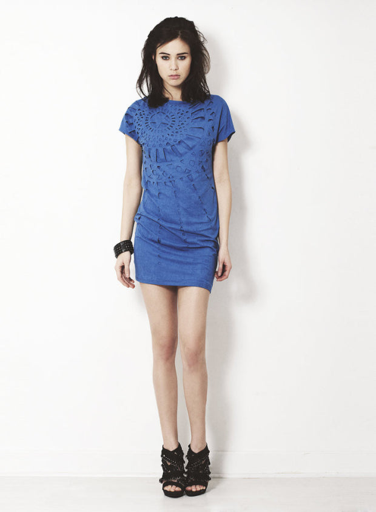

In [4]:
# 이 셀이 하는 일: 참조 사진을 불러오는 헬퍼 함수를 정의하고, 본인이 원하는 참조 사진을 업로드합니다.
# Stable Diffusion 1.5는 8의 배수 크기를 기대하므로 맞춰 리사이즈합니다.

def load_reference_image(source: str, max_side: int = 512) -> Image.Image:
    image = load_image(source).convert("RGB")

    w, h = image.size
    scale = min(max_side / max(w, h), 1.0)
    w, h = int(w * scale), int(h * scale)

    w = max(8, (w // 8) * 8)
    h = max(8, (h // 8) * 8)
    return image.resize((w, h))


from google.colab import files
print("포즈 1로 쓸 참조 사진을 업로드하세요 (전신이 잘 보이는 사진 추천).")
uploaded = files.upload()
POSE_01_SOURCE = next(iter(uploaded))

reference_image_01 = load_reference_image(POSE_01_SOURCE)
reference_image_01

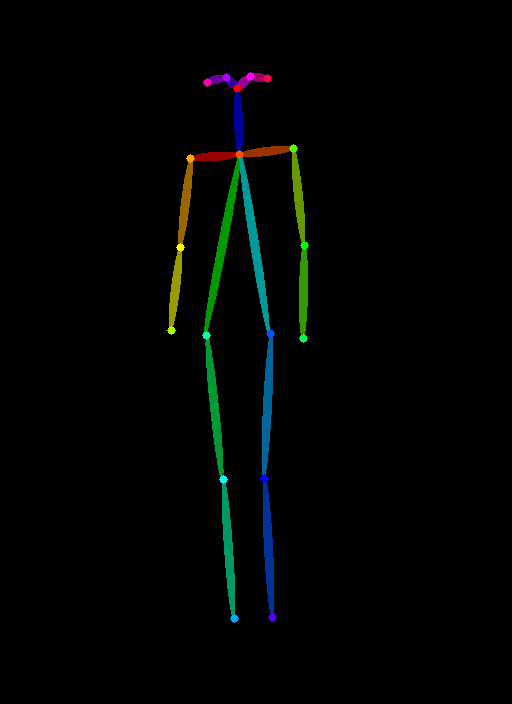

In [5]:
# 이 셀이 하는 일: OpenPose 검출기를 불러오고, 참조 사진에서 관절 스켈레톤을 추출합니다.
# 추출된 스켈레톤 이미지가 ControlNet에 들어갈 '포즈 조건'입니다.

openpose_detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")


def extract_pose(reference_image: Image.Image) -> Image.Image:
    return openpose_detector(reference_image, hand_and_face=False)


pose_skeleton_01 = extract_pose(reference_image_01)
pose_skeleton_01.save(os.path.join(SAMPLES_DIR, "pose_01.png"))
pose_skeleton_01

In [6]:
# 이 셀이 하는 일: ControlNet(포즈)과 Stable Diffusion 1.5 파이프라인을 로드합니다.
# T4 같은 작은 GPU에서도 안전하게 돌아가도록 model_cpu_offload를 켭니다.

BASE_MODEL = "stable-diffusion-v1-5/stable-diffusion-v1-5"
CONTROLNET_MODEL = "lllyasviel/sd-controlnet-openpose"

controlnet = ControlNetModel.from_pretrained(CONTROLNET_MODEL, torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    BASE_MODEL,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()  # GPU 메모리가 넉넉하면 pipe.to("cuda")로 바꿔도 됩니다.

print("모델 로드 완료!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:208: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


...

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


모델 로드 완료!


In [7]:
# 이 셀이 하는 일: '포즈 + 프롬프트 -> 이미지' 전체 과정을 하나의 함수(도구)로 묶습니다.
# 이 함수 하나가 이번 과제의 핵심 도구입니다: 참조 사진과 원하는 프롬프트만 주면 같은 자세의 새 이미지를 만들어 줍니다.

def generate_pose_image(
    pose_reference_source: str,
    prompt: str,
    output_name: str,
    negative_prompt: str = "blurry, low quality, distorted anatomy, extra limbs",
    controlnet_conditioning_scale: float = 1.0,
    num_inference_steps: int = 25,
    guidance_scale: float = 7.5,
    seed: int = 0,
):
    reference_image = load_reference_image(pose_reference_source)
    pose_image = extract_pose(reference_image)
    pose_image.save(os.path.join(SAMPLES_DIR, f"{output_name}_pose.png"))

    generator = torch.Generator(device="cpu").manual_seed(seed)
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=pose_image,
        width=pose_image.width,
        height=pose_image.height,
        controlnet_conditioning_scale=controlnet_conditioning_scale,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
    ).images[0]

    output_path = os.path.join(SAMPLES_DIR, f"{output_name}.png")
    result.save(output_path)
    print("저장 완료:", output_path)
    return result, pose_image

  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/output_01.png


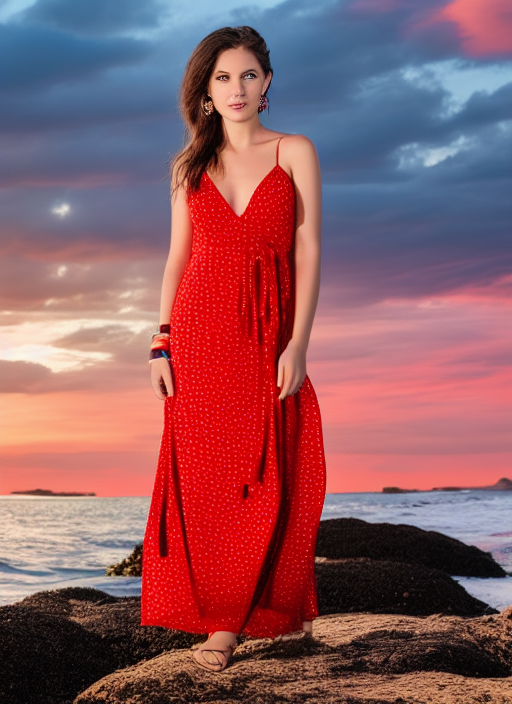

In [11]:
# 이 셀이 하는 일: 도구를 처음으로 한 번 돌려서 기준(baseline) 결과를 만듭니다.
# 결과는 samples/output_01.png 로 저장됩니다.

baseline_prompt = "a girl in a flowing red dress standing on a beach at sunset"

output_image_01, _ = generate_pose_image(
    pose_reference_source=POSE_01_SOURCE,
    prompt=baseline_prompt,
    output_name="output_01",
    seed=0,
)
output_image_01

## 2단계 — 다른 포즈와 프롬프트로 바꿔보기

(1) 같은 포즈, 다른 프롬프트 3개 / (2) 같은 프롬프트, 다른 포즈 사진 하나. 어느 쪽을 바꿀 때 결과가 크게 달라지는지 관찰합니다.

실제 프롬프트 목록은 [prompts.md](prompts.md)에도 정리되어 있습니다.

In [9]:
# 이 셀이 하는 일: 실험 A - 포즈는 pose_01로 고정하고, 프롬프트만 바꿔가며 3장을 생성합니다.

prompt_variants = [
    "a knight in shining armor standing in a medieval castle courtyard, dramatic lighting",
    "a ballet dancer in a white tutu on a theater stage, spotlight, soft focus background",
    "a robot made of chrome metal standing in a futuristic city street at night, neon lights",
]

experiment_a_results = []
for i, prompt in enumerate(prompt_variants, start=1):
    image, _ = generate_pose_image(
        pose_reference_source=POSE_01_SOURCE,
        prompt=prompt,
        output_name=f"expA_samepose_prompt{i}",
        seed=i,
    )
    experiment_a_results.append(image)

  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/expA_samepose_prompt1.png


  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/expA_samepose_prompt2.png


  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/expA_samepose_prompt3.png


pose_01과는 다른 자세가 뚜렷한 사람 사진을 업로드하세요 (예: 팔을 벌리거나 앉아 있는 사진).


Saving image2.jpg to image2 (2).jpg


  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/output_02.png


  0%|          | 0/25 [00:00<?, ?it/s]

저장 완료: samples/expB_samepromt_pose01.png


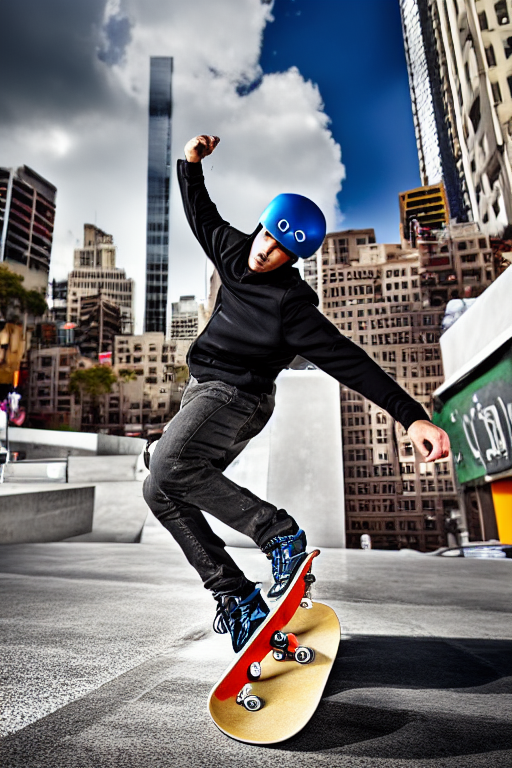

In [15]:
# 이 셀이 하는 일: 실험 B - 프롬프트는 고정하고, pose_01과는 다른 자세의 참조 사진(pose_02)을 넣어 결과를 비교합니다.
# pose_02는 과제 취지에 맞게 '직접 고른 사람 사진'을 씁니다. Colab에서 실행 중이면 업로드 창이 뜹니다.

try:
    from google.colab import files
    print("pose_01과는 다른 자세가 뚜렷한 사람 사진을 업로드하세요 (예: 팔을 벌리거나 앉아 있는 사진).")
    uploaded = files.upload()
    POSE_02_SOURCE = next(iter(uploaded))
except ModuleNotFoundError:
    POSE_02_SOURCE = "pose_02_input.jpg"  # Colab이 아니면 이 경로에 본인 사진을 넣어두세요.

fixed_prompt = "a professional skateboarder in mid-trick, urban street background, dynamic action photo"

reference_image_02 = load_reference_image(POSE_02_SOURCE)
pose_skeleton_02 = extract_pose(reference_image_02)
pose_skeleton_02.save(os.path.join(SAMPLES_DIR, "pose_02.png"))

output_image_02, _ = generate_pose_image(
    pose_reference_source=POSE_02_SOURCE,
    prompt=fixed_prompt,
    output_name="output_02",
    seed=0,
)

# 같은 프롬프트를 pose_01에도 적용해서 나란히 비교합니다.
output_image_01_same_prompt, _ = generate_pose_image(
    pose_reference_source=POSE_01_SOURCE,
    prompt=fixed_prompt,
    output_name="expB_samepromt_pose01",
    seed=0,
)
output_image_02

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

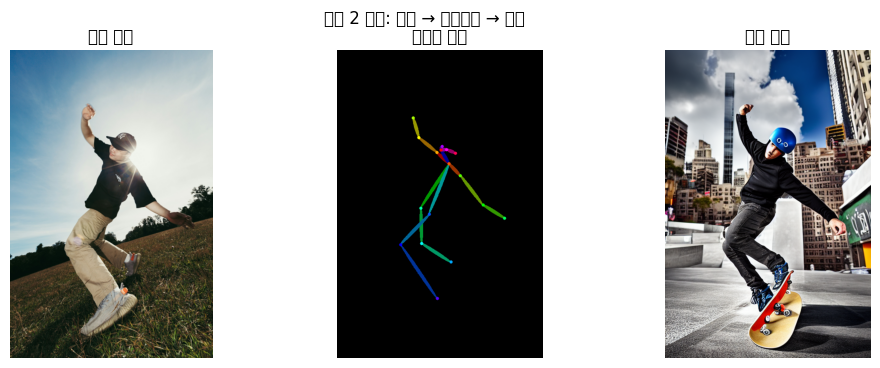

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("포즈 2 비교: 원본 → 스켈레톤 → 결과")

axes[0].imshow(reference_image_02)
axes[0].set_title("원본 사진")
axes[0].axis("off")

axes[1].imshow(pose_skeleton_02)
axes[1].set_title("추출된 포즈")
axes[1].axis("off")

axes[2].imshow(output_image_02)
axes[2].set_title("생성 결과")
axes[2].axis("off")

plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


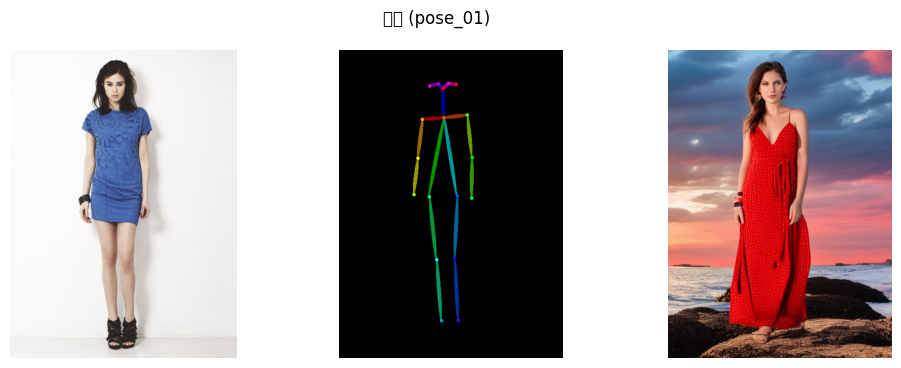

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

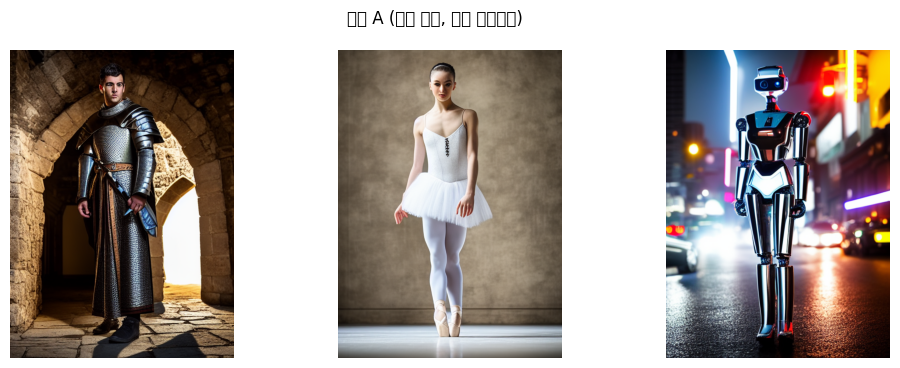

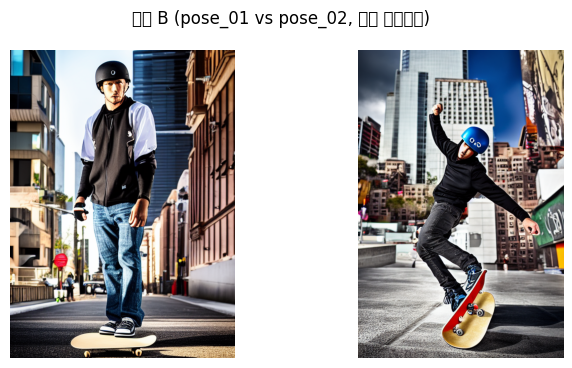

In [14]:
# 이 셀이 하는 일: 지금까지 만든 결과들을 한 번에 그리드로 띄워서 비교하기 쉽게 보여줍니다.
import matplotlib.pyplot as plt

rows = [
    ("기준 (pose_01)", [reference_image_01, pose_skeleton_01, output_image_01]),
    ("실험 A (같은 포즈, 다른 프롬프트)", experiment_a_results),
    ("실험 B (pose_01 vs pose_02, 같은 프롬프트)", [output_image_01_same_prompt, output_image_02]),
]

for title, images in rows:
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    fig.suptitle(title)
    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis("off")
    plt.show()

## 관찰 결과 (2단계 정리)

> 아래는 실제로 위 셀들을 Colab에서 실행한 뒤 관찰한 내용으로 채워 넣는 칸입니다. (Colab에서 실행 후 작성)

- **같은 포즈, 다른 프롬프트 (실험 A)**: (실행 후 작성 — 예: 자세/구도는 유지되지만 인물·배경·스타일은 프롬프트를 크게 따라갔는가?)
- **같은 프롬프트, 다른 포즈 (실험 B)**: (실행 후 작성 — 예: 팔다리 각도, 몸의 방향이 포즈 사진을 얼마나 그대로 따라갔는가?)
- **어느 쪽을 바꿨을 때 결과가 크게 달라졌는가**: (실행 후 작성)
- **잘 안 따라온 부분이 있다면**: (실행 후 작성 — 예: 손가락/얼굴 디테일, 조명 방향, controlnet_conditioning_scale 값에 따른 차이 등)